# EDA - Banorte Cross-Border Transactions

Exploración inicial del dataset `banorte_xb`: estructura, nulos, distribuciones y tendencias temporales.

## 1. Setup e imports

In [4]:
#from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")

DATA_DIR = Path("../data/raw/banorte_xb")

## 2. Carga de datos

Cargamos los **últimos 4 meses** disponibles. Los archivos están organizados como `{year}/{month}.parquet`, así que ordenamos y tomamos los últimos 4.

In [21]:
N_MONTHS = 4

all_files = sorted(DATA_DIR.rglob("*.parquet"))
files = all_files[-N_MONTHS:]

print(f"Archivos totales disponibles: {len(all_files)}")
print(f"Cargando últimos {N_MONTHS}:")
for f in files:
    print(f"  {f.relative_to(DATA_DIR)}")

Archivos totales disponibles: 28
Cargando últimos 4:
  2025\12.parquet
  2026\01.parquet
  2026\02.parquet
  2026\03.parquet


In [22]:
dfs = []
for f in files:
    df_tmp = pd.read_parquet(f)
    year, month = f.parts[-2], f.stem
    df_tmp["year_month"] = f"{year}-{month}"
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
print(f"Total filas: {df.shape[0]:,}")
print(f"Total columnas: {df.shape[1]}")

Total filas: 5,868,722
Total columnas: 20


## 3. Vista general del esquema

In [7]:
df.dtypes.to_frame("dtype").rename_axis("column")

,dtype
column,
CARD_TYPE,object
FEE_DATE,object
CARD_ISSUER,object
OPERATION_TYPE,object
AMOUNT_GROSS,object
AMOUNT_INSTALLMENT,object
PROVIDER,object
INSTALLMENTS,object
PAYMENT_AMOUNT,object


In [23]:
df.head(3)

,CARD_TYPE,FEE_DATE,CARD_ISSUER,OPERATION_TYPE,AMOUNT_GROSS,AMOUNT_INSTALLMENT,PROVIDER,INSTALLMENTS,PAYMENT_AMOUNT,MERCHANT_NAME,CARD_SCHEME,CONFIRM_DATE,CAMARA_COMPENSACION,CUSTO_TRANSACAO,FEE_EBANX,AMOUNT_IVA_INSTALLMENT,NET_AMOUNT,IVA_EBANX,AFILIACION,year_month
0,CREDIT,2025-12-04,BANCOMER,payment,63.2700000000,0.0000000000,banorte,1,63.2700000000,Temu.com,visa,2025-12-04,BANCOMER,0.017,1.0755900000,0.000000000000,62.0223156000,0.172094400000,09267749,2025-12
1,DEBIT,2025-12-04,BANCOMER,payment,150.0000000000,0.0000000000,banorte,1,150.0000000000,Canva,visa,2025-12-04,BANCOMER,0.017,2.5500000000,0.000000000000,147.0420000000,0.408000000000,09357577,2025-12
2,CREDIT,2025-12-04,INVEX,payment,674.6300000000,0.0000000000,banorte,1,674.6300000000,Amazon Retail MX,mastercard,2025-12-04,PROSA,0.017,11.4687100000,0.000000000000,661.3262964000,1.834993600000,08704594,2025-12


## 4. Análisis de nulos

In [24]:
total = len(df)
null_summary = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().sum() / total * 100).round(2),
    "non_null_count": df.notnull().sum(),
}).sort_values("null_pct", ascending=False)

null_summary

,null_count,null_pct,non_null_count
CARD_ISSUER,19809,0.34,5848913
CUSTO_TRANSACAO,9117,0.16,5859605
FEE_DATE,0,0.00,5868722
CARD_TYPE,15,0.00,5868707
OPERATION_TYPE,0,0.00,5868722
AMOUNT_GROSS,0,0.00,5868722
PROVIDER,0,0.00,5868722
AMOUNT_INSTALLMENT,0,0.00,5868722
PAYMENT_AMOUNT,0,0.00,5868722
MERCHANT_NAME,0,0.00,5868722


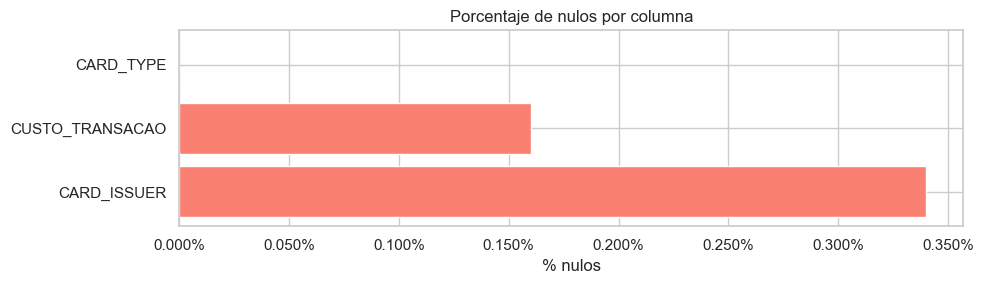

In [12]:
cols_with_nulls = null_summary[null_summary["null_count"] > 0]
if cols_with_nulls.empty:
    print("Sin columnas con nulos.")
else:
    fig, ax = plt.subplots(figsize=(10, max(3, len(cols_with_nulls) * 0.5)))
    ax.barh(cols_with_nulls.index, cols_with_nulls["null_pct"], color="salmon")
    ax.set_xlabel("% nulos")
    ax.set_title("Porcentaje de nulos por columna")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.show()

## 5. Conversión de tipos

Todas las columnas vienen como `string` desde Snowflake. Convertimos las columnas numéricas y de fecha.

In [25]:
NUMERIC_COLS = [
    "AMOUNT_GROSS",
    "AMOUNT_INSTALLMENT",
    "INSTALLMENTS",
    "CUSTO_TRANSACAO",
    "FEE_EBANX",
    "AMOUNT_IVA_INSTALLMENT",
    "NET_AMOUNT",
    "IVA_EBANX",
]
DATE_COLS = ["FEE_DATE", "CONFIRM_DATE"]
CATEGORICAL_COLS = [
    "CARD_TYPE",
    "CARD_ISSUER",
    "OPERATION_TYPE",
    "CARD_SCHEME",
    "AFILIACION",
    "MERCHANT_NAME",
    "CAMARA_COMPENSACION",
]

for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

print("Tipos actualizados:")
df.dtypes

Tipos actualizados:


CARD_TYPE                         object
FEE_DATE                  datetime64[ns]
CARD_ISSUER                       object
OPERATION_TYPE                    object
AMOUNT_GROSS                     float64
AMOUNT_INSTALLMENT               float64
PROVIDER                          object
INSTALLMENTS                       int64
PAYMENT_AMOUNT                    object
MERCHANT_NAME                     object
CARD_SCHEME                       object
CONFIRM_DATE              datetime64[ns]
CAMARA_COMPENSACION               object
CUSTO_TRANSACAO                  float64
FEE_EBANX                        float64
AMOUNT_IVA_INSTALLMENT           float64
NET_AMOUNT                       float64
IVA_EBANX                        float64
AFILIACION                        object
year_month                        object
dtype: object

## 6. Estadísticas descriptivas - columnas numéricas

In [26]:
numeric_existing = [c for c in NUMERIC_COLS if c in df.columns]
df[numeric_existing].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
AMOUNT_GROSS,"5,868,722.00",434.39,"1,963.39",0.01,5.00,10.00,44.00,150.00,383.03,"1,428.13","3,982.95","430,180.17"
AMOUNT_INSTALLMENT,"5,868,722.00",0.19,24.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"15,648.78"
INSTALLMENTS,"5,868,722.00",1.02,0.34,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,12.00
CUSTO_TRANSACAO,"5,859,605.00",0.02,0.00,0.01,0.01,0.01,0.02,0.02,0.02,0.02,0.02,0.03
FEE_EBANX,"5,868,722.00",7.10,33.29,0.00,0.09,0.17,0.73,2.53,5.95,23.25,66.74,"7,313.06"
AMOUNT_IVA_INSTALLMENT,"5,868,722.00",0.03,3.88,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"2,503.80"
NET_AMOUNT,"5,868,722.00",425.94,"1,921.27",0.01,4.90,9.81,43.13,147.04,376.18,"1,400.67","3,904.13","421,697.02"
IVA_EBANX,"5,868,722.00",1.14,5.33,0.00,0.01,0.03,0.12,0.41,0.95,3.72,10.68,"1,170.09"


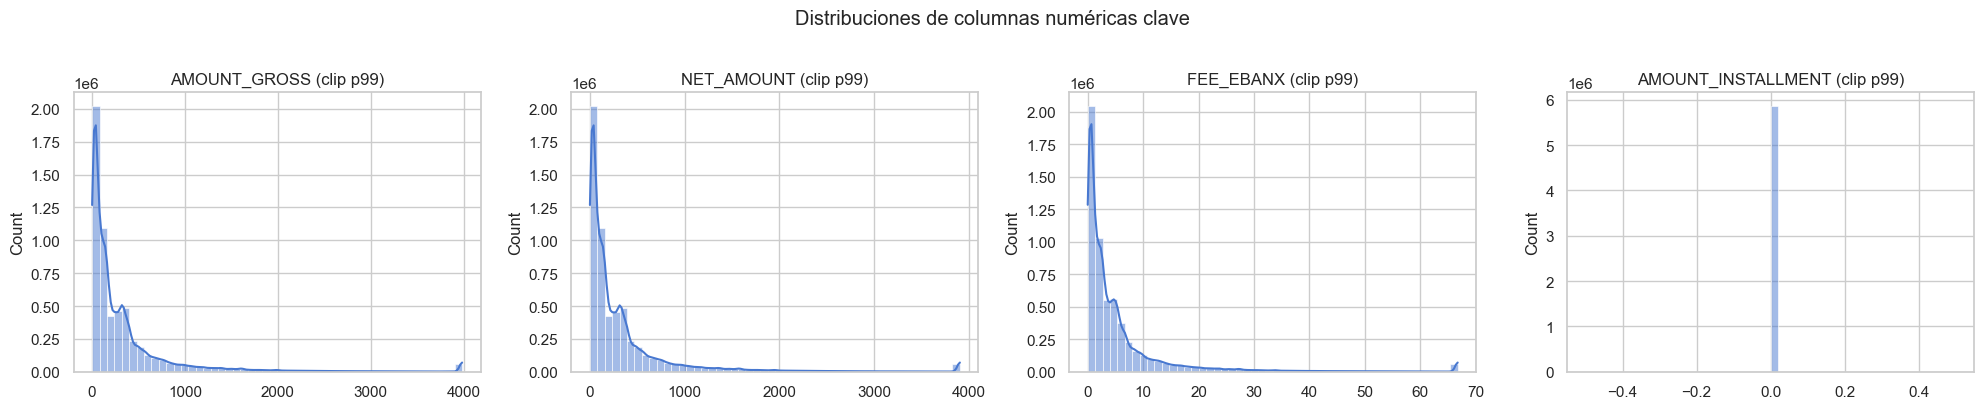

In [15]:
key_numeric = [c for c in ["AMOUNT_GROSS", "NET_AMOUNT", "FEE_EBANX", "AMOUNT_INSTALLMENT"] if c in df.columns]

fig, axes = plt.subplots(1, len(key_numeric), figsize=(5 * len(key_numeric), 4))
if len(key_numeric) == 1:
    axes = [axes]

for ax, col in zip(axes, key_numeric):
    data = df[col].dropna()
    clip_val = data.quantile(0.99)
    sns.histplot(data.clip(upper=clip_val), ax=ax, bins=50, kde=True)
    ax.set_title(f"{col} (clip p99)")
    ax.set_xlabel("")

plt.suptitle("Distribuciones de columnas numéricas clave", y=1.02)
plt.tight_layout()
plt.show()

## 7. Análisis de columnas categóricas

In [27]:
cat_existing = [c for c in CATEGORICAL_COLS if c in df.columns]

cat_summary = pd.DataFrame({
    "unique_values": df[cat_existing].nunique(),
    "top_value": df[cat_existing].apply(lambda s: s.value_counts().index[0] if s.notna().any() else None),
    "top_freq": df[cat_existing].apply(lambda s: s.value_counts().iloc[0] if s.notna().any() else 0),
    "top_freq_pct": df[cat_existing].apply(
        lambda s: round(s.value_counts().iloc[0] / s.notna().sum() * 100, 2) if s.notna().any() else 0
    ),
})
cat_summary

,unique_values,top_value,top_freq,top_freq_pct
CARD_TYPE,4,DEBIT,4528417,77.16
CARD_ISSUER,250,BANCOMER,2873743,49.13
OPERATION_TYPE,3,payment,5604851,95.50
CARD_SCHEME,3,visa,4370767,74.48
AFILIACION,33,09580171,2360287,40.22
MERCHANT_NAME,20,Google Play,2371591,40.41
CAMARA_COMPENSACION,6,BANCOMER,2873743,48.97


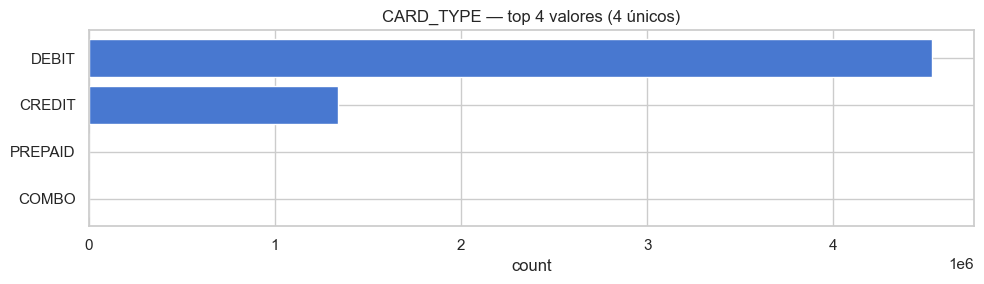

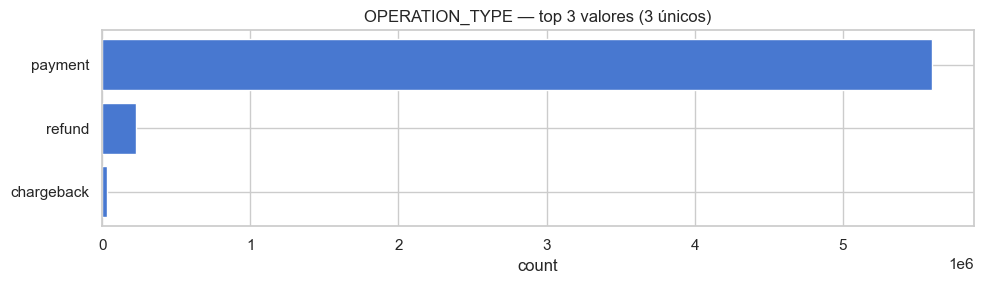

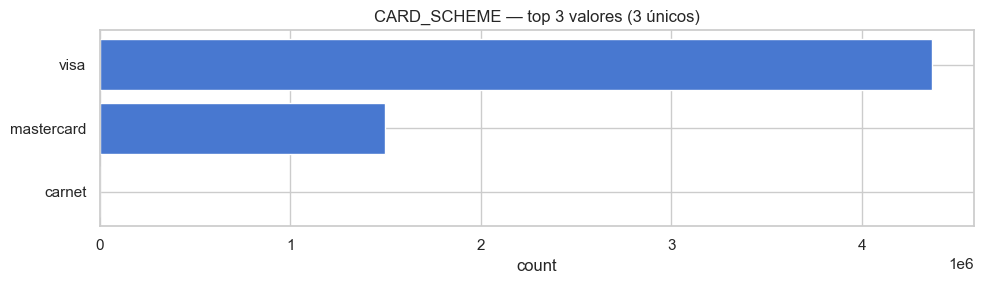

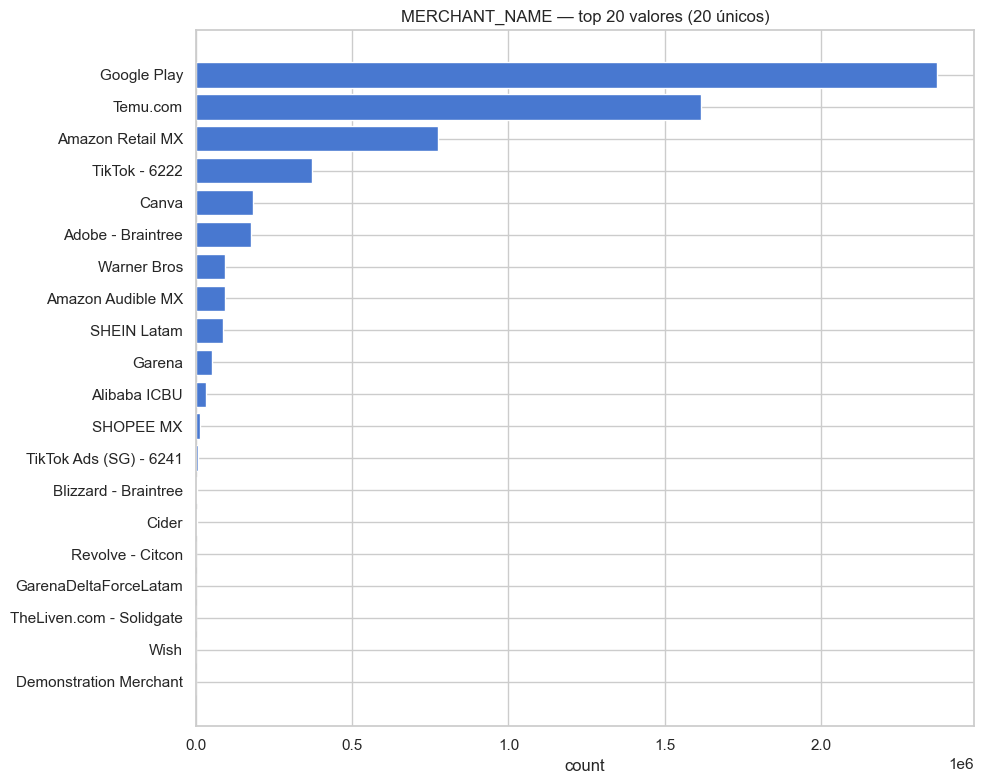

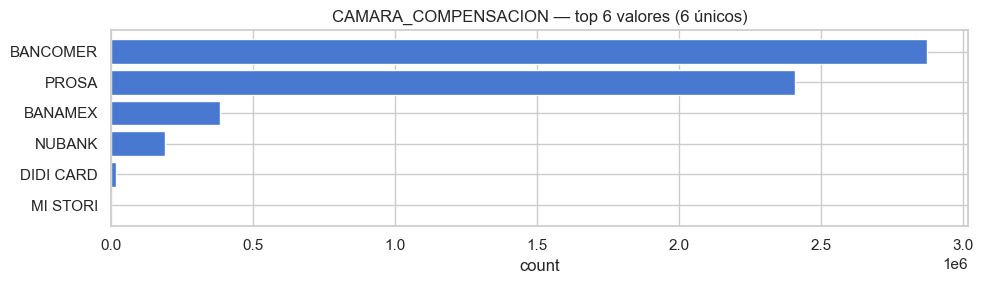

In [28]:
# Value counts para cada categórica de baja cardinalidad
low_card = [c for c in cat_existing if df[c].nunique() <= 30]

for col in low_card:
    vc = df[col].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(10, max(3, len(vc) * 0.4)))
    ax.barh(vc.index[::-1].astype(str), vc.values[::-1])
    ax.set_title(f"{col} — top {len(vc)} valores ({df[col].nunique()} únicos)")
    ax.set_xlabel("count")
    plt.tight_layout()
    plt.show()

## 8. Análisis temporal

C:\Users\Santiago\AppData\Local\Temp\ipykernel_23016\221635471.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(monthly["fee_ym"], rotation=45, ha="right")
C:\Users\Santiago\AppData\Local\Temp\ipykernel_23016\221635471.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(monthly["fee_ym"], rotation=45, ha="right")
C:\Users\Santiago\AppData\Local\Temp\ipykernel_23016\221635471.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(monthly["fee_ym"], rotation=45, ha="right")


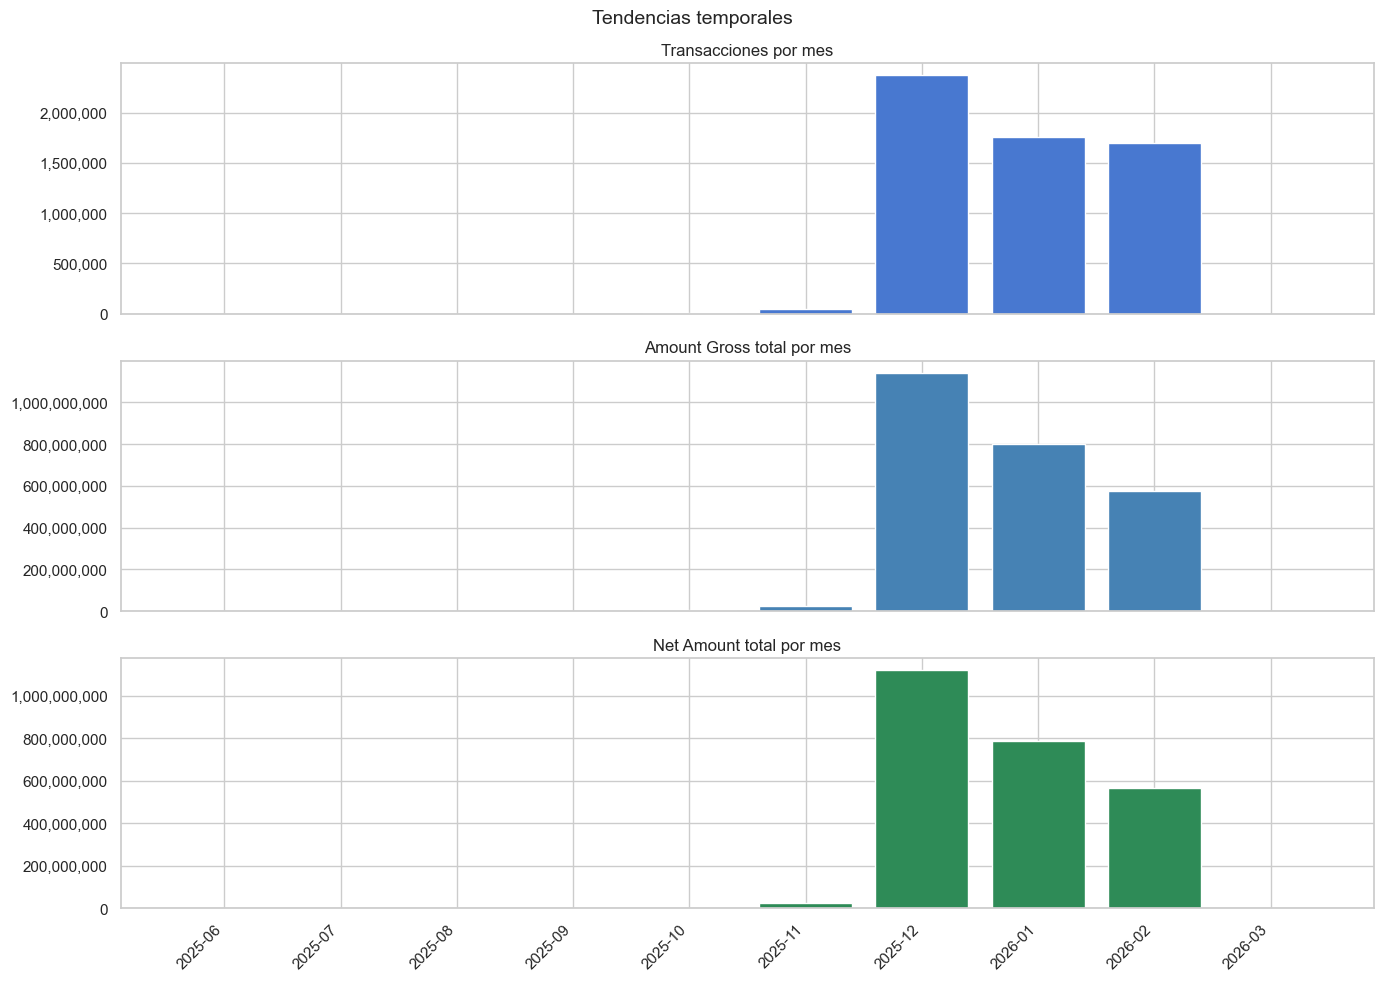

In [29]:
if "FEE_DATE" in df.columns:
    df["fee_ym"] = df["FEE_DATE"].dt.to_period("M")
    monthly = df.groupby("fee_ym").agg(
        transactions=("fee_ym", "count"),
        amount_gross_sum=("AMOUNT_GROSS", "sum") if "AMOUNT_GROSS" in df.columns else ("fee_ym", "count"),
        net_amount_sum=("NET_AMOUNT", "sum") if "NET_AMOUNT" in df.columns else ("fee_ym", "count"),
    ).reset_index()
    monthly["fee_ym"] = monthly["fee_ym"].astype(str)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    axes[0].bar(monthly["fee_ym"], monthly["transactions"])
    axes[0].set_title("Transacciones por mes")
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    if "AMOUNT_GROSS" in df.columns:
        axes[1].bar(monthly["fee_ym"], monthly["amount_gross_sum"], color="steelblue")
        axes[1].set_title("Amount Gross total por mes")
        axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    if "NET_AMOUNT" in df.columns:
        axes[2].bar(monthly["fee_ym"], monthly["net_amount_sum"], color="seagreen")
        axes[2].set_title("Net Amount total por mes")
        axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    for ax in axes:
        ax.set_xticklabels(monthly["fee_ym"], rotation=45, ha="right")

    plt.suptitle("Tendencias temporales", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No hay columna FEE_DATE disponible.")

## 9. Análisis de archivos de fuente (year_month)

Verifica consistencia entre el mes del archivo y la fecha real de los registros.

In [30]:
rows_per_file = df.groupby("year_month").size().reset_index(name="rows")
rows_per_file["rows"] = rows_per_file["rows"].map("{:,}".format)
rows_per_file

,year_month,rows
0,2025-12,"2,371,260"
1,2026-01,"1,783,309"
2,2026-02,"1,714,152"
3,2026-03,1


## 10. Correlaciones entre columnas numéricas

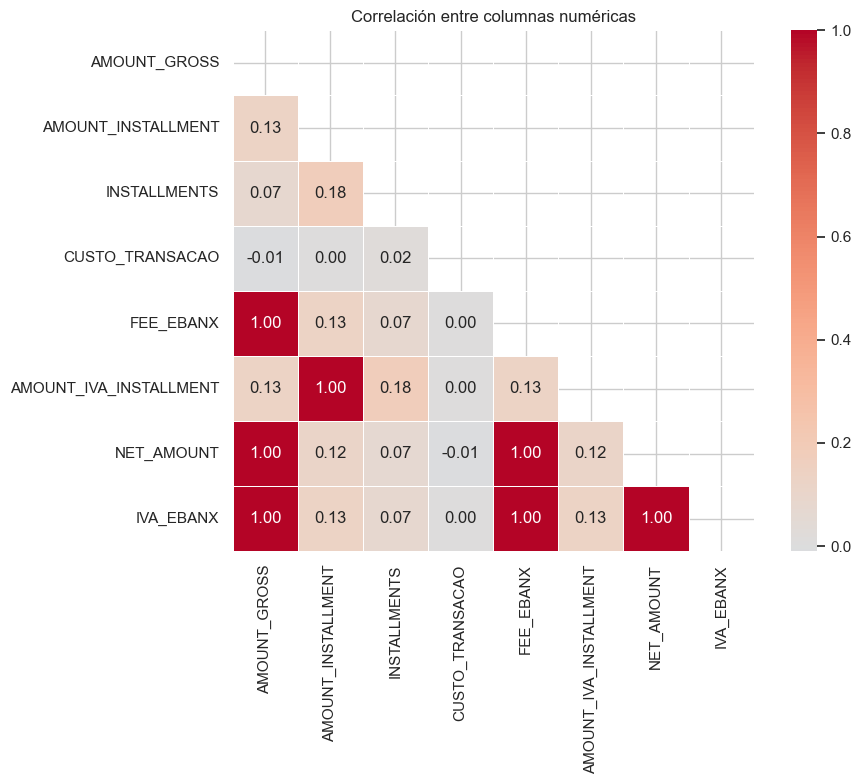

In [31]:
corr_cols = [c for c in NUMERIC_COLS if c in df.columns]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    square=True,
    linewidths=0.5,
)
ax.set_title("Correlación entre columnas numéricas")
plt.tight_layout()
plt.show()

## 11. Outliers - boxplots

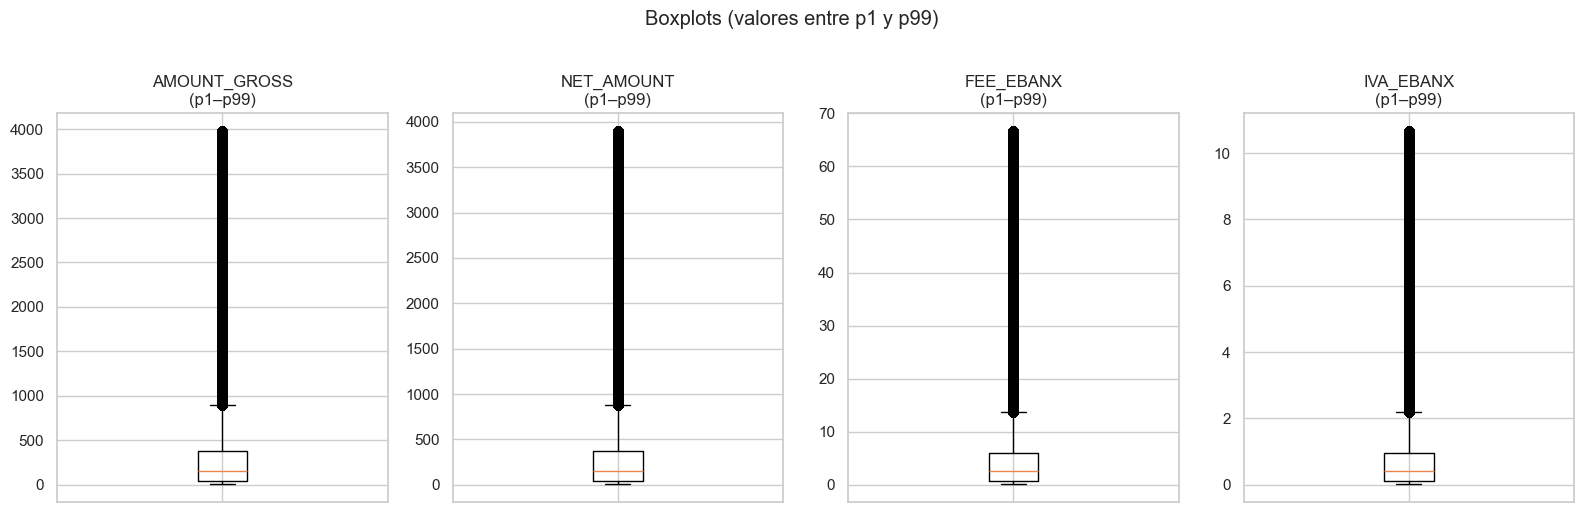

In [32]:
key_amounts = [c for c in ["AMOUNT_GROSS", "NET_AMOUNT", "FEE_EBANX", "IVA_EBANX"] if c in df.columns]

fig, axes = plt.subplots(1, len(key_amounts), figsize=(4 * len(key_amounts), 5))
if len(key_amounts) == 1:
    axes = [axes]

for ax, col in zip(axes, key_amounts):
    data = df[col].dropna()
    p1, p99 = data.quantile(0.01), data.quantile(0.99)
    ax.boxplot(data.clip(p1, p99), vert=True)
    ax.set_title(f"{col}\n(p1–p99)")
    ax.set_xticklabels([""])

plt.suptitle("Boxplots (valores entre p1 y p99)", y=1.02)
plt.tight_layout()
plt.show()

## 12. Resumen ejecutivo

In [33]:
print("=" * 60)
print("RESUMEN DEL DATASET banorte_xb")
print("=" * 60)
print(f"Total filas:       {len(df):>15,}")
print(f"Total columnas:    {df.shape[1]:>15}")
print(f"Archivos leídos:   {len(files):>15}")
if "FEE_DATE" in df.columns:
    print(f"Rango de fechas:   {df['FEE_DATE'].min().date()} → {df['FEE_DATE'].max().date()}")
print()
print("Columnas con nulos:")
for _, row in null_summary[null_summary["null_count"] > 0].iterrows():
    print(f"  {_.ljust(30)} {row['null_pct']:>6.2f}%  ({row['null_count']:,} nulos)")
if null_summary[null_summary["null_count"] > 0].empty:
    print("  (ninguna)")
print()
if "AMOUNT_GROSS" in df.columns:
    print(f"AMOUNT_GROSS  media:    {df['AMOUNT_GROSS'].mean():>12,.2f}")
    print(f"AMOUNT_GROSS  mediana:  {df['AMOUNT_GROSS'].median():>12,.2f}")
    print(f"AMOUNT_GROSS  std:      {df['AMOUNT_GROSS'].std():>12,.2f}")
print("=" * 60)

RESUMEN DEL DATASET banorte_xb
Total filas:             5,868,722
Total columnas:                 21
Archivos leídos:                 4
Rango de fechas:   2025-06-04 → 2026-03-02

Columnas con nulos:
  CARD_ISSUER                      0.34%  (19,809.0 nulos)
  CUSTO_TRANSACAO                  0.16%  (9,117.0 nulos)
  CARD_TYPE                        0.00%  (15.0 nulos)

AMOUNT_GROSS  media:          434.39
AMOUNT_GROSS  mediana:        150.00
AMOUNT_GROSS  std:          1,963.39
